# EDA Fourcasters

Ce notebook sert à faire un premier état des lieux des tables produites par dbt.
On regarde les volumes, les dates, les valeurs manquantes et quelques
répartitions utiles pour préparer Power BI et un futur modèle de ML.

> Attention : le niveau Météo-France est un **danger prévu**, pas un relevé
> du nombre de feux réellement observés. La table ML contient donc des
> variables candidates, mais pas encore de cible d'apprentissage.

In [1]:
import pandas as pd
from google.cloud import bigquery

PROJET_GCP = "fourcasters-openmeteo-loick"
DATASET = "openmeteo_analyse"
client = bigquery.Client(project=PROJET_GCP)

def lire_requete(sql):
    """Exécute une requête et renvoie un DataFrame."""
    return client.query(sql).to_dataframe()

## 1. Volumes et période couverte

In [2]:
volumes = lire_requete(f"""
SELECT 'fact_meteo' AS table_nom, COUNT(*) AS lignes,
       MIN(date) AS date_min, MAX(date) AS date_max
FROM `{PROJET_GCP}.{DATASET}.fact_meteo`
UNION ALL
SELECT 'fact_danger_incendie', COUNT(*), MIN(date_publication), MAX(date_publication)
FROM `{PROJET_GCP}.{DATASET}.fact_danger_incendie`
UNION ALL
SELECT 'pbi_risque_incendie', COUNT(*), MIN(date_publication), MAX(date_publication)
FROM `{PROJET_GCP}.{DATASET}.pbi_risque_incendie`
UNION ALL
SELECT 'ml_features_incendie', COUNT(*), MIN(date_publication), MAX(date_publication)
FROM `{PROJET_GCP}.{DATASET}.ml_features_incendie`
ORDER BY table_nom
""")
volumes

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,table_nom,lignes,date_min,date_max
0,fact_danger_incendie,19776,2026-05-28,2026-09-07
1,fact_meteo,3507120,2000-01-01,2026-09-02
2,ml_features_incendie,9888,2026-05-28,2026-09-07
3,pbi_risque_incendie,19776,2026-05-28,2026-09-07


## 2. Valeurs manquantes dans la table Power BI

In [3]:
manquants = lire_requete(f"""
SELECT
  COUNT(*) AS lignes,
  COUNTIF(NOT meteo_disponible) AS lignes_sans_meteo,
  ROUND(100 * COUNTIF(NOT meteo_disponible) / COUNT(*), 2) AS pct_sans_meteo,
  COUNTIF(temperature_moyenne IS NULL) AS temperature_manquante,
  COUNTIF(precipitations_totales IS NULL) AS precipitation_manquante
FROM `{PROJET_GCP}.{DATASET}.pbi_risque_incendie`
""")
manquants

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,lignes,lignes_sans_meteo,pct_sans_meteo,temperature_manquante,precipitation_manquante
0,19776,960,4.85,960,960


## 3. Quelques indicateurs météo

In [4]:
resume_meteo = lire_requete(f"""
SELECT
  EXTRACT(YEAR FROM date) AS annee,
  ROUND(AVG(temperature_moyenne), 1) AS temperature_moyenne,
  ROUND(MAX(temperature_maximale), 1) AS temperature_maximale,
  ROUND(SUM(precipitations_totales), 1) AS precipitations_totales
FROM `{PROJET_GCP}.{DATASET}.fact_meteo`
GROUP BY annee
ORDER BY annee
""")
resume_meteo

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,annee,temperature_moyenne,temperature_maximale,precipitations_totales
0,2000,11.9,37.3,351754.3
1,2001,11.6,38.2,346250.9
2,2002,12.1,36.5,343156.1
3,2003,12.4,41.6,270272.5
4,2004,11.6,38.4,282786.1
5,2005,11.6,37.2,254287.2
6,2006,12.2,37.8,307902.8
7,2007,11.8,37.7,308585.2
8,2008,11.4,36.5,339541.4
9,2009,11.8,38.3,294239.7


## 4. Répartition du danger prévu

In [5]:
repartition_danger = lire_requete(f"""
SELECT
  echeance,
  niveau_danger,
  COUNT(*) AS lignes,
  ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY echeance), 2) AS pct
FROM `{PROJET_GCP}.{DATASET}.fact_danger_incendie`
GROUP BY echeance, niveau_danger
ORDER BY echeance, niveau_danger
""")
repartition_danger

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,echeance,niveau_danger,lignes,pct
0,J1,1,3810,38.53
1,J1,2,4235,42.83
2,J1,3,1749,17.69
3,J1,4,94,0.95
4,J2,1,4256,43.04
5,J2,2,4333,43.82
6,J2,3,1254,12.68
7,J2,4,45,0.46


## 5. Qualité de la couverture météo

In [6]:
POINTS_ATTENDUS = 360
couverture_meteo = lire_requete(f"""
WITH jours AS (
  SELECT date, COUNT(DISTINCT code_insee) AS points
  FROM `{PROJET_GCP}.{DATASET}.fact_meteo`
  GROUP BY date
)
SELECT
  COUNT(*) AS jours,
  MIN(points) AS minimum_points,
  MAX(points) AS maximum_points,
  COUNTIF(points != {POINTS_ATTENDUS}) AS jours_incomplets
FROM jours
""")
couverture_meteo

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,jours,minimum_points,maximum_points,jours_incomplets
0,9742,360,360,0


Si `jours_incomplets` est supérieur à zéro, il faut vérifier les communes
manquantes avant de comparer les départements entre eux.

## 6. Couverture par département

In [7]:
couverture_departements = lire_requete(f"""
SELECT
  numero_departement,
  ANY_VALUE(departement) AS departement,
  COUNT(DISTINCT date) AS jours_meteo,
  MIN(date) AS date_min,
  MAX(date) AS date_max
FROM `{PROJET_GCP}.{DATASET}.int_meteo_departement_jour`
GROUP BY numero_departement
ORDER BY jours_meteo, numero_departement
""")
couverture_departements.head(10)

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,numero_departement,departement,jours_meteo,date_min,date_max
0,01,Ain,9742,2000-01-01,2026-09-02
1,02,Aisne,9742,2000-01-01,2026-09-02
2,03,Allier,9742,2000-01-01,2026-09-02
3,04,Alpes-de-Haute-Provence,9742,2000-01-01,2026-09-02
4,05,Hautes-Alpes,9742,2000-01-01,2026-09-02
5,06,Alpes-Maritimes,9742,2000-01-01,2026-09-02
6,07,Ardèche,9742,2000-01-01,2026-09-02
7,08,Ardennes,9742,2000-01-01,2026-09-02
8,09,Ariège,9742,2000-01-01,2026-09-02
9,10,Aube,9742,2000-01-01,2026-09-02


Cette vue permet de repérer les départements qui ont une période météo plus
courte. C'est important avant de tirer des conclusions géographiques.

## 7. Danger prévu et météo associée

In [8]:
danger_meteo = lire_requete(f"""
SELECT
  echeance,
  niveau_danger,
  COUNT(*) AS lignes,
  ROUND(AVG(temperature_moyenne), 1) AS temperature_moyenne,
  ROUND(AVG(precipitations_totales), 2) AS precipitations_moyennes,
  ROUND(AVG(rafale_vent_maximale), 1) AS rafale_moyenne
FROM `{PROJET_GCP}.{DATASET}.pbi_risque_incendie`
WHERE meteo_disponible
GROUP BY echeance, niveau_danger
ORDER BY echeance, niveau_danger
""")
danger_meteo

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,echeance,niveau_danger,lignes,temperature_moyenne,precipitations_moyennes,rafale_moyenne
0,J1,1,3578,20.5,9.18,38.4
1,J1,2,4016,24.3,2.17,35.9
2,J1,3,1720,27.1,0.69,35.2
3,J1,4,94,28.5,0.25,47.6
4,J2,1,3964,21.1,8.02,38.1
5,J2,2,4160,24.5,2.32,35.8
6,J2,3,1239,26.9,1.01,36.0
7,J2,4,45,27.9,0.86,53.7


Cette comparaison est descriptive uniquement. Elle ne prouve pas qu'une
variable météo cause un niveau de danger, car le niveau Météo-France est
une prévision produite avec d'autres informations.

## 8. Contrôle des variables ML

In [9]:
controle_ml = lire_requete(f"""
SELECT
  COUNT(*) AS lignes,
  COUNT(DISTINCT id_feature) AS identifiants_uniques,
  COUNTIF(NOT meteo_disponible) AS lignes_sans_meteo,
  COUNTIF(temperature_moyenne_7j IS NULL) AS temperature_7j_manquante,
  MIN(date_publication) AS premiere_publication,
  MAX(date_publication) AS derniere_publication
FROM `{PROJET_GCP}.{DATASET}.ml_features_incendie`
""")
controle_ml

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,lignes,identifiants_uniques,lignes_sans_meteo,temperature_7j_manquante,premiere_publication,derniere_publication
0,9888,9888,384,384,2026-05-28,2026-09-07


Une ligne ML correspond à un couple date de publication-département. Les
variables météo sur sept jours s'arrêtent à la veille de la publication.
Il faudra encore joindre une cible d'incendie réellement observé avant
d'entraîner un modèle supervisé.

## 9. Premiers graphiques

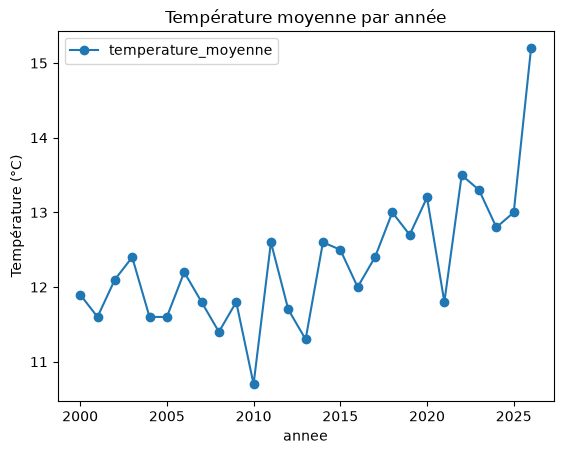

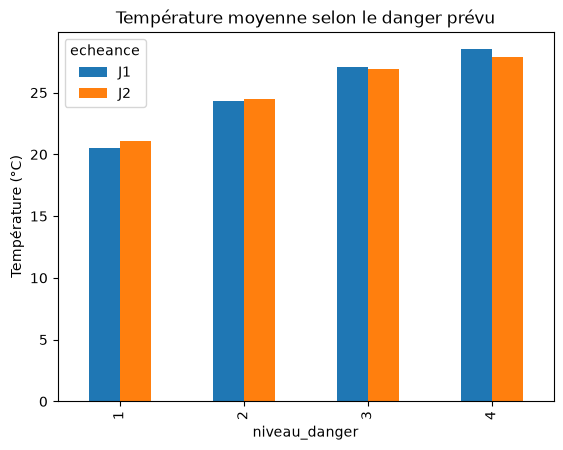

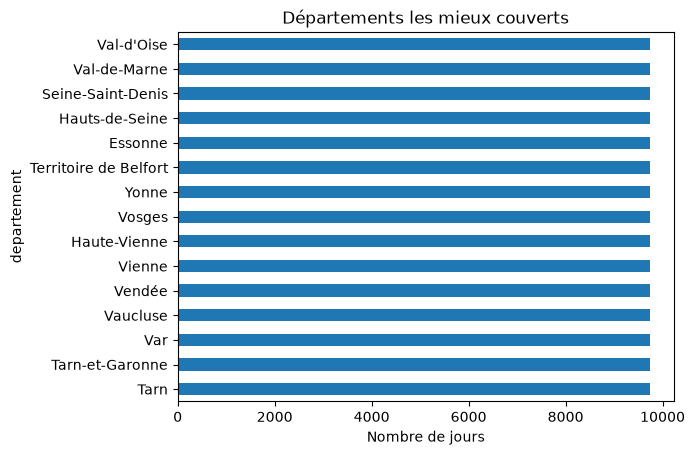

In [10]:
# Graphiques facultatifs : matplotlib n'est pas nécessaire pour le pipeline quotidien.
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Installe matplotlib pour afficher les graphiques : uv add matplotlib")
else:
    resume_meteo.plot(x="annee", y="temperature_moyenne", marker="o")
    plt.title("Température moyenne par année")
    plt.ylabel("Température (°C)")
    plt.show()

    danger_meteo.pivot(index="niveau_danger", columns="echeance", values="temperature_moyenne").plot(kind="bar")
    plt.title("Température moyenne selon le danger prévu")
    plt.ylabel("Température (°C)")
    plt.show()

    couverture_departements.sort_values("jours_meteo").tail(15).plot(
        x="departement", y="jours_meteo", kind="barh", legend=False
    )
    plt.title("Départements les mieux couverts")
    plt.xlabel("Nombre de jours")
    plt.show()

## 10. Questions à garder pour la suite

À compléter après l'exécution du notebook :

- quelles années ou périodes présentent le plus de danger prévu ?
- les niveaux élevés sont-ils concentrés dans certains départements ?
- les variables météo sont-elles suffisamment complètes pour le ML ?
- quelle source peut fournir la cible d'incendies observés ?

Ces questions guideront la suite de l'analyse. Les résultats doivent être
interprétés avec les limites de couverture et sans confondre danger prévu
et incendie réellement déclenché.

## 11. Statistiques détaillées des variables météo

In [11]:
statistiques_meteo = lire_requete(f"""
WITH variables AS (
  SELECT statistique.nom, statistique.valeur
  FROM `{PROJET_GCP}.{DATASET}.fact_meteo`,
  UNNEST([
    STRUCT('temperature_moyenne' AS nom, SAFE_CAST(temperature_moyenne AS FLOAT64) AS valeur),
    STRUCT('temperature_minimale' AS nom, SAFE_CAST(temperature_minimale AS FLOAT64) AS valeur),
    STRUCT('temperature_maximale' AS nom, SAFE_CAST(temperature_maximale AS FLOAT64) AS valeur),
    STRUCT('temperature_ressentie_moyenne' AS nom, SAFE_CAST(temperature_ressentie_moyenne AS FLOAT64) AS valeur),
    STRUCT('temperature_ressentie_minimale' AS nom, SAFE_CAST(temperature_ressentie_minimale AS FLOAT64) AS valeur),
    STRUCT('temperature_ressentie_maximale' AS nom, SAFE_CAST(temperature_ressentie_maximale AS FLOAT64) AS valeur),
    STRUCT('humidite_moyenne' AS nom, SAFE_CAST(humidite_moyenne AS FLOAT64) AS valeur),
    STRUCT('humidite_minimale' AS nom, SAFE_CAST(humidite_minimale AS FLOAT64) AS valeur),
    STRUCT('humidite_maximale' AS nom, SAFE_CAST(humidite_maximale AS FLOAT64) AS valeur),
    STRUCT('point_de_rosee_moyen' AS nom, SAFE_CAST(point_de_rosee_moyen AS FLOAT64) AS valeur),
    STRUCT('precipitations_totales' AS nom, SAFE_CAST(precipitations_totales AS FLOAT64) AS valeur),
    STRUCT('pluie_totale' AS nom, SAFE_CAST(pluie_totale AS FLOAT64) AS valeur),
    STRUCT('neige_totale' AS nom, SAFE_CAST(neige_totale AS FLOAT64) AS valeur),
    STRUCT('heures_de_precipitations' AS nom, SAFE_CAST(heures_de_precipitations AS FLOAT64) AS valeur),
    STRUCT('vitesse_vent_moyenne' AS nom, SAFE_CAST(vitesse_vent_moyenne AS FLOAT64) AS valeur),
    STRUCT('vitesse_vent_maximale' AS nom, SAFE_CAST(vitesse_vent_maximale AS FLOAT64) AS valeur),
    STRUCT('rafale_vent_maximale' AS nom, SAFE_CAST(rafale_vent_maximale AS FLOAT64) AS valeur),
    STRUCT('couverture_nuageuse_moyenne' AS nom, SAFE_CAST(couverture_nuageuse_moyenne AS FLOAT64) AS valeur),
    STRUCT('pression_moyenne' AS nom, SAFE_CAST(pression_moyenne AS FLOAT64) AS valeur),
    STRUCT('duree_ensoleillement' AS nom, SAFE_CAST(duree_ensoleillement AS FLOAT64) AS valeur),
    STRUCT('rayonnement_solaire_total' AS nom, SAFE_CAST(rayonnement_solaire_total AS FLOAT64) AS valeur),
    STRUCT('evapotranspiration' AS nom, SAFE_CAST(evapotranspiration AS FLOAT64) AS valeur),
    STRUCT('deficit_pression_vapeur_maximal' AS nom, SAFE_CAST(deficit_pression_vapeur_maximal AS FLOAT64) AS valeur),
    STRUCT('humidite_sol_0_7cm' AS nom, SAFE_CAST(humidite_sol_0_7cm AS FLOAT64) AS valeur),
    STRUCT('humidite_sol_7_28cm' AS nom, SAFE_CAST(humidite_sol_7_28cm AS FLOAT64) AS valeur),
    STRUCT('humidite_sol_28_100cm' AS nom, SAFE_CAST(humidite_sol_28_100cm AS FLOAT64) AS valeur),
    STRUCT('temperature_sol_0_7cm' AS nom, SAFE_CAST(temperature_sol_0_7cm AS FLOAT64) AS valeur)
  ]) AS statistique
)
SELECT
  nom,
  COUNTIF(valeur IS NOT NULL) AS valeurs,
  COUNTIF(valeur IS NULL) AS valeurs_manquantes,
  ROUND(AVG(valeur), 2) AS moyenne,
  ROUND(STDDEV(valeur), 2) AS ecart_type,
  ROUND(APPROX_QUANTILES(valeur, 4)[SAFE_OFFSET(1)], 2) AS premier_quartile,
  ROUND(APPROX_QUANTILES(valeur, 4)[SAFE_OFFSET(2)], 2) AS mediane,
  ROUND(APPROX_QUANTILES(valeur, 4)[SAFE_OFFSET(3)], 2) AS troisieme_quartile,
  ROUND(MIN(valeur), 2) AS minimum,
  ROUND(MAX(valeur), 2) AS maximum
FROM variables
GROUP BY nom
ORDER BY nom
""")
statistiques_meteo

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,nom,valeurs,valeurs_manquantes,moyenne,ecart_type,premier_quartile,mediane,troisieme_quartile,minimum,maximum
0,couverture_nuageuse_moyenne,3507120,0,61.54,29.43,41.00,68.00,86.00,0.00,100.00
1,deficit_pression_vapeur_maximal,3507120,0,0.91,0.75,0.37,0.70,1.23,0.00,7.73
2,duree_ensoleillement,3507120,0,31477.56,15936.95,21493.68,33546.22,44523.99,0.00,57600.00
3,evapotranspiration,3507120,0,2.37,1.67,0.92,2.03,3.50,0.10,12.36
4,heures_de_precipitations,3507120,0,4.21,5.82,0.00,1.00,7.00,0.00,24.00
5,humidite_maximale,3507120,0,90.78,8.05,88.00,93.00,96.00,24.00,100.00
6,humidite_minimale,3507120,0,59.33,15.12,49.00,59.00,71.00,9.00,100.00
7,humidite_moyenne,3507120,0,76.25,11.52,69.00,78.00,85.00,15.00,100.00
8,humidite_sol_0_7cm,3507120,0,0.33,0.08,0.29,0.35,0.39,0.04,0.74
9,humidite_sol_28_100cm,3507120,0,0.32,0.07,0.27,0.33,0.38,0.05,0.72


Cette table donne une lecture univariée complète : nombre de valeurs,
valeurs manquantes, moyenne, dispersion, quartiles, minimum et maximum.
La direction du vent n'est pas moyennée car c'est une variable circulaire.

## 12. Variations selon l'année et la saison

In [12]:
statistiques_saison = lire_requete(f"""
SELECT
  d.annee,
  d.saison,
  COUNT(*) AS observations,
  ROUND(AVG(m.temperature_moyenne), 2) AS temperature_moyenne,
  ROUND(MIN(m.temperature_minimale), 2) AS temperature_minimale,
  ROUND(MAX(m.temperature_maximale), 2) AS temperature_maximale,
  ROUND(AVG(m.humidite_moyenne), 2) AS humidite_moyenne,
  ROUND(SUM(m.precipitations_totales), 2) AS precipitations_totales,
  ROUND(MAX(m.rafale_vent_maximale), 2) AS rafale_maximale
FROM `{PROJET_GCP}.{DATASET}.fact_meteo` AS m
INNER JOIN `{PROJET_GCP}.{DATASET}.dim_date` AS d
  ON m.date = d.date
GROUP BY d.annee, d.saison
ORDER BY d.annee, d.saison
""")
statistiques_saison

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,annee,saison,observations,temperature_moyenne,temperature_minimale,temperature_maximale,humidite_moyenne,precipitations_totales,rafale_maximale
0,2000,Automne,32760,12.43,-16.1,32.5,80.28,118030.1,135.0
1,2000,Hiver,32760,5.73,-20.0,20.8,83.62,66629.7,108.7
2,2000,Printemps,33120,10.88,-11.6,28.7,76.51,88774.6,97.9
3,2000,Été,33120,18.43,-0.7,37.3,72.10,78319.9,101.5
4,2001,Automne,32760,11.92,-16.5,30.6,80.55,78789.3,115.6
...,...,...,...,...,...,...,...,...,...
103,2025,Été,33120,21.26,2.9,40.9,65.53,65007.4,84.6
104,2026,Automne,720,19.95,3.8,33.9,65.27,86.6,49.0
105,2026,Hiver,21240,6.33,-22.1,24.0,85.29,89518.2,134.6
106,2026,Printemps,33120,12.79,-15.7,36.4,72.09,60708.7,103.7


Cette vue aide à repérer les périodes chaudes, sèches ou venteuses. Les
résultats doivent rester comparables uniquement entre périodes suffisamment
couvertes par les données.

## 13. Comparaison entre départements

In [13]:
statistiques_departements = lire_requete(f"""
SELECT
  numero_departement,
  ANY_VALUE(departement) AS departement,
  ROUND(AVG(temperature_moyenne), 2) AS temperature_moyenne,
  ROUND(MIN(temperature_minimale), 2) AS temperature_minimale,
  ROUND(MAX(temperature_maximale), 2) AS temperature_maximale,
  ROUND(AVG(humidite_moyenne), 2) AS humidite_moyenne,
  ROUND(SUM(precipitations_totales), 2) AS precipitations_totales,
  ROUND(MAX(rafale_vent_maximale), 2) AS rafale_maximale,
  COUNT(DISTINCT date) AS jours
FROM `{PROJET_GCP}.{DATASET}.int_meteo_departement_jour`
GROUP BY numero_departement
ORDER BY temperature_moyenne DESC
""")

print("Départements les plus chauds en moyenne")
statistiques_departements.head(10)

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Départements les plus chauds en moyenne


,numero_departement,departement,temperature_moyenne,temperature_minimale,temperature_maximale,humidite_moyenne,precipitations_totales,rafale_maximale,jours
0,2B,Haute-Corse,16.48,-10.1,38.8,74.16,62321.9,132.5,9742
1,2A,Corse-du-Sud,15.51,-8.0,37.4,75.12,71337.8,141.1,9742
2,13,Bouches-du-Rhône,15.37,-10.0,43.7,67.65,82943.9,102.2,9742
3,83,Var,15.25,-14.5,39.3,70.69,56066.3,106.2,9742
4,84,Vaucluse,14.79,-14.3,43.7,66.87,61114.5,108.7,9742
5,34,Hérault,14.74,-7.7,41.3,70.79,73597.2,115.9,9742
6,66,Pyrénées-Orientales,14.74,-10.6,40.6,71.51,59849.3,139.3,9742
7,30,Gard,14.61,-8.9,43.5,68.84,76528.7,108.7,9742
8,11,Aude,14.54,-9.3,41.3,73.73,60861.4,149.8,9742
9,06,Alpes-Maritimes,14.50,-16.4,37.2,75.61,76440.4,106.9,9742


In [14]:
print("Départements les plus humides en moyenne")
statistiques_departements.sort_values("humidite_moyenne", ascending=False).head(10)

print("Départements avec le plus de précipitations cumulées")
statistiques_departements.sort_values("precipitations_totales", ascending=False).head(10)

Départements les plus humides en moyenne
Départements avec le plus de précipitations cumulées


,numero_departement,departement,temperature_moyenne,temperature_minimale,temperature_maximale,humidite_moyenne,precipitations_totales,rafale_maximale,jours
94,74,Haute-Savoie,9.60,-27.9,35.7,76.92,211286.9,116.6,9742
83,68,Haut-Rhin,11.06,-20.2,37.1,77.23,195672.1,135.4,9742
71,01,Ain,11.61,-17.7,39.4,75.77,172419.0,113.0,9742
77,67,Bas-Rhin,11.36,-18.4,38.7,75.99,166886.0,121.7,9742
84,57,Moselle,11.05,-19.4,38.6,77.10,155949.9,125.3,9742
78,62,Pas-de-Calais,11.35,-14.2,38.3,79.53,142142.5,135.0,9742
81,59,Nord,11.25,-12.9,38.6,78.83,140263.4,130.0,9742
40,71,Saône-et-Loire,12.30,-16.6,39.8,74.84,130539.8,111.6,9742
65,73,Savoie,11.73,-23.0,37.3,76.43,126166.1,138.2,9742
45,65,Hautes-Pyrénées,12.20,-11.8,37.6,78.89,124307.8,133.9,9742


Ces classements sont utiles pour le reporting, mais ils dépendent du nombre
de jours disponibles dans chaque département. La colonne `jours` doit donc
toujours être regardée avec les moyennes.

## 14. Statistiques des variables préparées pour le ML

In [15]:
statistiques_ml = lire_requete(f"""
WITH variables AS (
  SELECT statistique.nom, statistique.valeur
  FROM `{PROJET_GCP}.{DATASET}.ml_features_incendie`,
  UNNEST([
    STRUCT('temperature_moyenne_7j' AS nom, SAFE_CAST(temperature_moyenne_7j AS FLOAT64) AS valeur),
    STRUCT('temperature_maximale_7j' AS nom, SAFE_CAST(temperature_maximale_7j AS FLOAT64) AS valeur),
    STRUCT('humidite_moyenne_7j' AS nom, SAFE_CAST(humidite_moyenne_7j AS FLOAT64) AS valeur),
    STRUCT('precipitations_7j' AS nom, SAFE_CAST(precipitations_7j AS FLOAT64) AS valeur),
    STRUCT('rafale_vent_maximale_7j' AS nom, SAFE_CAST(rafale_vent_maximale_7j AS FLOAT64) AS valeur),
    STRUCT('deficit_pression_vapeur_maximal_7j' AS nom, SAFE_CAST(deficit_pression_vapeur_maximal_7j AS FLOAT64) AS valeur),
    STRUCT('jours_sans_pluie_7j' AS nom, SAFE_CAST(jours_sans_pluie_7j AS FLOAT64) AS valeur)
  ]) AS statistique
)
SELECT
  nom,
  COUNTIF(valeur IS NOT NULL) AS valeurs,
  COUNTIF(valeur IS NULL) AS valeurs_manquantes,
  ROUND(AVG(valeur), 2) AS moyenne,
  ROUND(MIN(valeur), 2) AS minimum,
  ROUND(MAX(valeur), 2) AS maximum,
  ROUND(STDDEV(valeur), 2) AS ecart_type
FROM variables
GROUP BY nom
ORDER BY nom
""")
statistiques_ml

c:\dev\Projet_Fourcasters\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,nom,valeurs,valeurs_manquantes,moyenne,minimum,maximum,ecart_type
0,deficit_pression_vapeur_maximal_7j,9504,384,3.84,0.83,7.23,1.22
1,humidite_moyenne_7j,9504,384,57.41,27.10,83.95,10.16
2,jours_sans_pluie_7j,9504,384,3.27,0.00,7.00,1.91
3,precipitations_7j,9504,384,30.61,0.00,361.60,40.69
4,rafale_vent_maximale_7j,9504,384,47.80,24.80,105.80,10.21
5,temperature_maximale_7j,9504,384,33.26,18.30,42.20,4.16
6,temperature_moyenne_7j,9504,384,23.50,13.64,31.84,3.68


## 15. Bilan général

Après l'exécution des cellules, le bilan doit répondre à quatre questions :

1. Les données sont-elles assez complètes et régulières ?
2. Quelles variables météo présentent les amplitudes les plus fortes ?
3. Les différences entre départements et saisons sont-elles cohérentes ?
4. Les variables ML sont-elles disponibles sans utiliser d'information future ?

Cette EDA décrit les données, mais ne permet pas encore de conclure sur les
causes des incendies. Il manque toujours une table d'incendies réellement
observés pour créer la cible du futur modèle.